# Read Data

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
accounts_df = pd.read_csv("moneycraft_accounts.csv")
closure_reasons = pd.read_csv("moneycraft_closure_reasons.csv")
spend_df = pd.read_csv("moneycraft_marketing_spend.csv")

In [6]:
grouped = accounts.groupby('customer_id')

signup_month = grouped['month'].min()   # First month
last_active = grouped['month'].max()   # last month
tenure_months = grouped['month'].count()    # total tenure
channel = grouped['acquisition_channel'].first()
age_band = grouped['age_band'].first()
region = grouped['region'].first()
first_plan = grouped['account_tier'].first()
last_plan = grouped['account_tier'].last()
total_revenue = grouped['monthly_fee'].sum()
max_paid = grouped['monthly_fee'].max()
# ever_paid = grouped['monthly_fee' > 0]

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0


## Total marketing spend / share of marketing spend over time

In [19]:
import pandas as pd

df = pd.read_csv('moneycraft_marketing_spend.csv')

# Total spend per month
total_spend = df.groupby('month')['spend_gbp'].sum().rename('total_spend')

# Spend per month per channel (pivoted into columns)
total_spend_channel = df.pivot_table(index='month', columns='channel', values='spend_gbp', aggfunc='sum')
total_spend_channel.columns = ['branch', 'broker', 'comp', 'online', 'out', 'refer']

# Combine into one dataframe
marketing = total_spend.to_frame().join(total_spend_channel).reset_index()

marketing.head()

,month,total_spend,branch,broker,comp,online,out,refer
0,2022-01,25202.0,7310.0,4014.0,3162.0,3945.0,4899.0,1872.0
1,2022-02,25260.0,7882.0,1989.0,3266.0,4231.0,5548.0,2344.0
2,2022-03,26444.0,6792.0,5159.0,2804.0,5394.0,4134.0,2161.0
3,2022-04,25805.0,9152.0,2358.0,2765.0,5239.0,4415.0,1876.0
4,2022-05,27488.0,7144.0,4637.0,3850.0,5145.0,4894.0,1818.0


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('moneycraft_marketing_spend.csv')

# Total spend per month
total_spend = df.groupby('month')['spend_gbp'].sum().rename('total_spend')

# Spend per month per channel
total_spend_channel = df.pivot_table(index='month', columns='channel', values='spend_gbp', aggfunc='sum')
total_spend_channel.columns = ['branch', 'broker', 'comp', 'online', 'out', 'refer']

# Combine into one dataframe
result = total_spend.to_frame().join(total_spend_channel).reset_index()

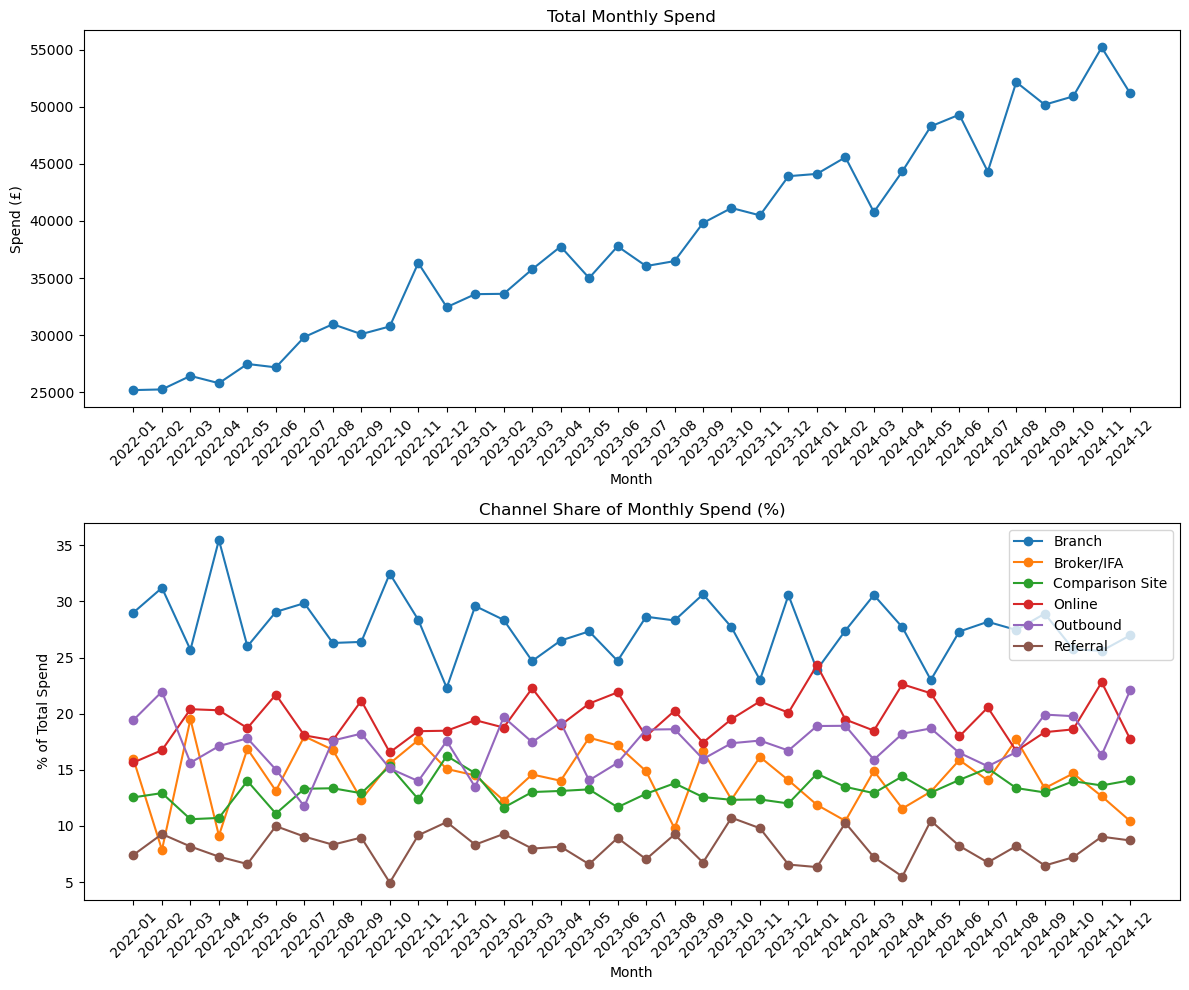

In [24]:
channels = ['branch', 'broker', 'comp', 'online', 'out', 'refer']

channel_map = {
    'branch': 'Branch',
    'broker': 'Broker/IFA',
    'comp': 'Comparison Site',
    'online': 'Online',
    'out': 'Outbound',
    'refer': 'Referral'
}

pct_df = result[channels].div(result['total_spend'], axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Total monthly spend
axes[0].plot(result['month'], result['total_spend'], marker='o')
axes[0].set_title('Total Monthly Spend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Spend (£)')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: % spend per channel
for actual_col, display_name in channel_map.items():
    axes[1].plot(result['month'], pct_df[actual_col], marker='o', label=display_name)

axes[1].set_title('Channel Share of Monthly Spend (%)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('% of Total Spend')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# CAC

In [53]:
# Isolate the true acquisition month for each unique customer
cohorts = accounts_df.groupby('customer_id').agg(
    acquisition_month=('month', 'min'), # column 'acquisition_month', the first month associated with each customer
    acquisition_channel=('acquisition_channel', 'first') # select first 'acquisition_channel' as doesn't change over time
).reset_index() # reset index to keep customer id as a normal column
cohorts.head()

,customer_id,acquisition_month,acquisition_channel
0,1,2022-01,Comparison Site
1,2,2022-01,Online
2,3,2022-01,Branch
3,4,2022-01,Referral
4,5,2022-01,Comparison Site


In [32]:
# Aggregate total volume of new sign-ups per month per channel
acquisition_counts = cohorts.groupby(['acquisition_month', 'acquisition_channel']).size().reset_index(name='new_customers')
acquisition_counts.head()

,acquisition_month,acquisition_channel,new_customers
0,2022-01,Branch,49
1,2022-01,Broker/IFA,21
2,2022-01,Comparison Site,81
3,2022-01,Online,58
4,2022-01,Outbound,39


In [34]:
# Standardize column names for clean merging
spend_df = spend_df.rename(columns={'channel': 'acquisition_channel', 'month': 'acquisition_month'})

In [56]:
# Merge spend data with acquisition numbers
cac_summary = pd.merge(spend_df, acquisition_counts, on=['acquisition_month', 'acquisition_channel'], how='left')
cac_summary.head()

,acquisition_month,acquisition_channel,spend_gbp,new_customers
0,2022-01,Branch,7310.0,49
1,2022-01,Broker/IFA,4014.0,21
2,2022-01,Comparison Site,3162.0,81
3,2022-01,Online,3945.0,58
4,2022-01,Outbound,4899.0,39


In [36]:
# Fill any NaN values if a channel had spend but zero acquisitions in a month
cac_summary['new_customers'] = cac_summary['new_customers'].fillna(0)

In [57]:
# Compute the Customer Acquisition Cost (CAC) - The price per customer for each channel, for each month
cac_summary['cac_gbp'] = cac_summary['spend_gbp'] / cac_summary['new_customers']
cac_summary.head()

,acquisition_month,acquisition_channel,spend_gbp,new_customers,cac_gbp
0,2022-01,Branch,7310.0,49,149.183673
1,2022-01,Broker/IFA,4014.0,21,191.142857
2,2022-01,Comparison Site,3162.0,81,39.037037
3,2022-01,Online,3945.0,58,68.017241
4,2022-01,Outbound,4899.0,39,125.615385


In [59]:
# Calculate total channel CAC by summing over time
channel_perf = cac_summary.groupby('acquisition_channel').agg(
    total_spend=('spend_gbp', 'sum'),
    total_acquired=('new_customers', 'sum')
).reset_index()
channel_perf['total_channel_cac'] = channel_perf['total_spend'] / channel_perf['total_acquired']

In [60]:
# Calculate company blended CAC (average CAC over all channels) as the baseline.
total_company_spend = channel_perf['total_spend'].sum()
total_company_acquired = channel_perf['total_acquired'].sum()

company_blended_cac = total_company_spend / total_company_acquired

# 
print(f"True Company Blended CAC: £{company_blended_cac:.2f}")
print("\n--- LIFETIME ACQUISITION METRICS BY CHANNEL ---")
print(channel_perf.to_string(index=False))

True Company Blended CAC: £87.44

--- LIFETIME ACQUISITION METRICS BY CHANNEL ---
acquisition_channel  total_spend  total_acquired  total_channel_cac
             Branch     377567.0            2481         152.183394
         Broker/IFA     195020.0             979         199.203269
    Comparison Site     182406.0            4584          39.791885
             Online     269322.0            3851          69.935601
           Outbound     239264.0            1962         121.949032
           Referral     112021.0            1875          59.744533


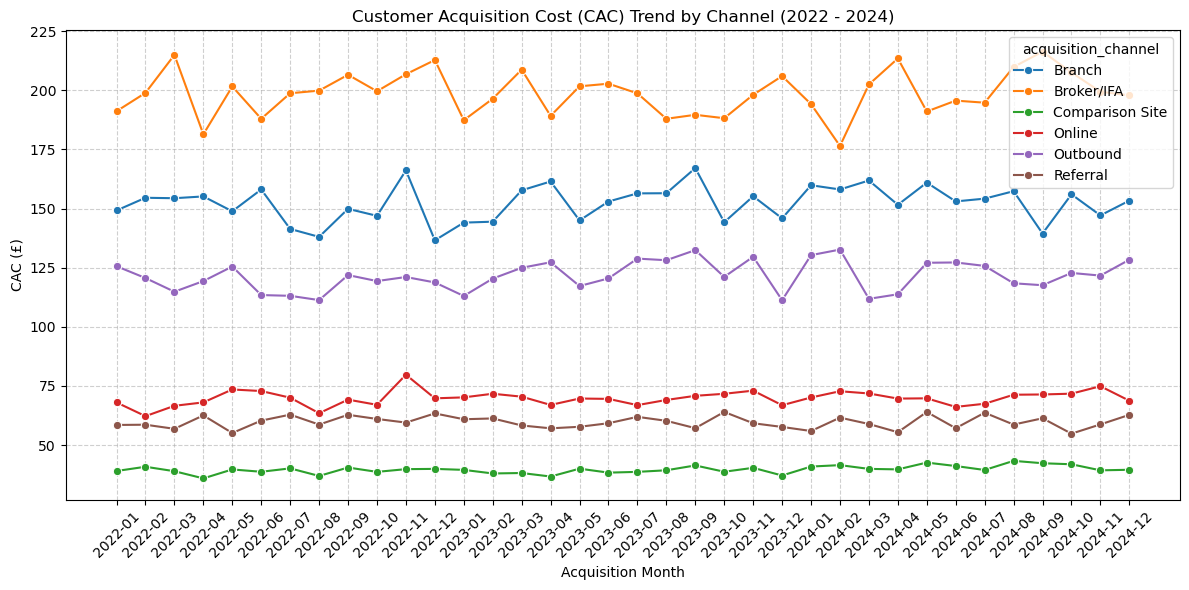

In [61]:
# 8. Plot CAC trends over time to identify efficiency drift
plt.figure(figsize=(12, 6))
sns.lineplot(data=cac_summary, x='acquisition_month', y='cac_gbp', hue='acquisition_channel', marker='o')
plt.title("Customer Acquisition Cost (CAC) Trend by Channel (2022 - 2024)")
plt.ylabel("CAC (£)")
plt.xlabel("Acquisition Month")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("cac_trends_over_time.png")
plt.show()

## Insights

1. Comparison Site, Referral and Online have the lowest CAC and are below the company average CAC, therefore on average bring in the most customers for every £ spent marketting those channels. Outbound, Branch, Broker are much higher.

**NOTE:** This must be compared with LTV of customers from different channels, since some channels may bring in higher paying customers (not all customers are created equally).

2. The CAC of each channel does not appear to vary noteably over the time period, assuming channels bring in roughly the same distribution of tiers over time, this means marketing efficiency has not decreased as the company has scaled. This suggests that we have not hit diminihing returns on our marketing channels and have not exhausted our core target audience, therefore we can confirm that the marketing team have developed a predictable and repeatable customer acquistion approach.